# در این مثال، ویژگی ها از یک داده ارتعاشی بیرینگ موتور استخراج شده و ویژگی های مهم با استفاده روش های مختلف انتخاب می شوند 

##   داده ارتعاشی از آدرس زیر دانلود و در پوشه کاری قرار داده شود
   https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/tree/main/ex3-1

In [2]:
# نصب کتابخانه های ناموجود
!pip install PyWavelets arabic_reshaper python_bidi

### 1. فراخوانی کتابخانه های مورد نیاز

In [3]:
import scipy.io as sio
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.signal import welch
import pywt
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

# تابع کمکی برای نمایش صحیح متون فارسی در نمودارها
def fa(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

# تنظیمات فارسی نویسی
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

### 2. بارگزاری داده

dict_keys(['__header__', '__version__', '__globals__', 'X176_DE_time', 'X176_FE_time', 'X176RPM'])
__header__ <class 'bytes'>
__version__ <class 'str'>
__globals__ <class 'list'>
X176_DE_time <class 'numpy.ndarray'>
 - shape: (487964, 1)
X176_FE_time <class 'numpy.ndarray'>
 - shape: (487964, 1)
X176RPM <class 'numpy.ndarray'>
 - shape: (1, 1)


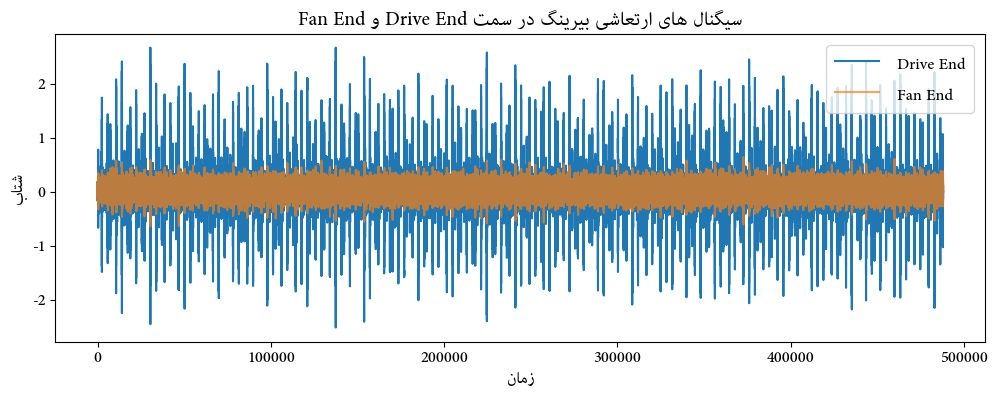

In [4]:
mat_data = sio.loadmat("IR014_2.mat")

#چاپ اطلاعات موجود در فایل داده ارتعاشی
print(mat_data.keys())
for k in mat_data.keys():
    v = mat_data[k]
    print(k, type(v))  #چاپ نوع داده ها
    if hasattr(v, 'shape'):
        print(f" - shape: {v.shape}") #در صورت عددی بودن داده، چاپ ابعاد داده ها

signal_de = mat_data['X176_DE_time'].flatten()
signal_fe = mat_data['X176_FE_time'].flatten()

# نمایش سیگنال ها
plt.figure(figsize=(12, 4))
plt.plot(signal_de, label="Drive End")
plt.plot(signal_fe, label="Fan End", alpha=0.7)
plt.xlabel(fa("زمان"))
plt.ylabel(fa("شتاب"))
plt.legend()
plt.title(fa("سیگنال های ارتعاشی بیرینگ در سمت Drive End و Fan End"))
plt.show()

### 3. پیش پردازش داده ها

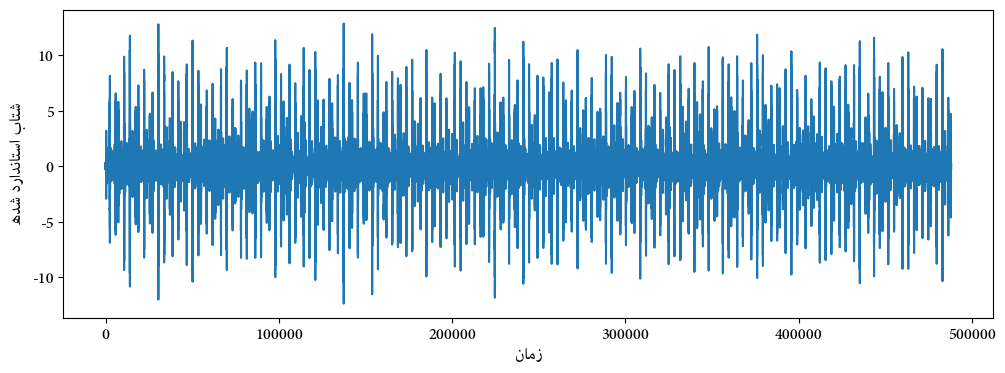

تعداد قطعات: 238


In [6]:
# معمولا سیگنال Drive End به خرابی حساس تر است و اطلاعات غنی تری دارد. لذا به عنوان سیگنال مورد بررسی در نظر گرفته می شود
signal = signal_de

def denoise_signal(sig):  #تابع نویز زدایی
    coeffs = pywt.wavedec(sig, 'db4', level=4)
    # نرم کردن ضرایب جزئی برای حذف نویز
    threshold = 0.04
    coeffs = [pywt.threshold(c, threshold*max(c)) for c in coeffs]
    return pywt.waverec(coeffs, 'db4')

signal = denoise_signal(signal)

#استانداردسازی (میانگین صفر و انحراف معیار 1)
signal = StandardScaler().fit_transform(signal.reshape(-1, 1)).flatten()

# نمایش سیگنال استانداردشده
plt.figure(figsize=(12, 4))
plt.plot(signal, label="Drive End")
plt.xlabel(fa("زمان"))
plt.ylabel(fa("شتاب استاندارد شده"))
plt.show()

# تبدیل سیگنال به قطعات کوچک جهت تحلیل
win_size = 2048
segments = [signal[i:i+win_size] for i in range(0, len(signal)-win_size, win_size)] 

print(f"تعداد قطعات: {len(segments)}")

### 4. استخراج ویژگی ها

In [7]:
def extract_features(sig, fs=12000): #نرخ نمونه برداری 12000 درنظر گرفته شده
    feats = {}
    # حوزه زمان
    feats["mean"] = np.mean(sig)
    feats["std"] = np.std(sig)
    feats["rms"] = np.sqrt(np.mean(sig**2))
    feats["kurtosis"] = pd.Series(sig).kurtosis()
    feats["skew"] = pd.Series(sig).skew()
    feats["ptp"] = np.ptp(sig)
    feats["crest"] = np.max(np.abs(sig)) / feats["rms"]
    
    # حوزه فرکانس
    f, Pxx = welch(sig, fs=fs)
    feats["dom_freq"] = f[np.argmax(Pxx)]
    feats["spec_energy"] = np.sum(Pxx)
    
    # حوزه زمان-فرکانس (Wavelet)
    coeffs = pywt.wavedec(sig, "db4", level=4)
    for i, c in enumerate(coeffs):
        feats[f"wavelet_energy_{i}"] = np.sum(c**2)
    
    return feats

all_features = [extract_features(seg) for seg in segments]
df = pd.DataFrame(all_features)

df.head()

,mean,std,rms,kurtosis,skew,ptp,crest,dom_freq,spec_energy,wavelet_energy_0,wavelet_energy_1,wavelet_energy_2,wavelet_energy_3,wavelet_energy_4
0,0.004686,0.447502,0.447527,8.074248,0.029275,6.119965,7.121542,609.375,0.004145,62.681528,211.648055,130.705067,5.511150,0.269699
1,0.009244,1.082502,1.082541,18.019322,0.344446,15.052444,7.524895,656.250,0.027749,80.609831,1244.255900,1059.276319,17.357685,0.481656
2,0.008407,0.919289,0.919328,19.052127,0.186378,12.760030,7.143237,656.250,0.018910,80.917803,1203.872193,438.594039,12.870365,0.302631
3,-0.002730,0.788859,0.788864,15.343308,0.415806,10.877213,7.360200,656.250,0.014996,79.304459,916.719459,272.990631,8.625649,0.361145
4,-0.004272,0.412124,0.412146,4.816099,-0.024530,4.285720,5.460735,656.250,0.003750,75.423811,136.043812,137.110474,5.322212,0.281282


### 5. انتخاب ویژگی ها

In [8]:
# --- روش فیلتر ---
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(df)
selected_features_filter = df.columns[selector.get_support()]

# --- روش پوششی (Wrapper) ---
best_score = -1
best_feats = None
for feat in df.columns:
    X_sub = df[[feat]]
    kmeans = KMeans(n_clusters=2, random_state=42).fit(X_sub)
    labels = kmeans.labels_
    score = silhouette_score(X_sub, labels)
    if score > best_score:
        best_score = score
        best_feats = [feat]

# --- روش جاسازی (Embedded) ---
X = df.values
y = df.sum(axis=1)  # برچسب مصنوعی (ساده ترین راه جمع همه ویژگی ها در هر ردیف)
# مدل های با ناظر مثل لاسو و جنگ تصادفی برای عملیات باید برچسب داشته باشند. 

# LASSO
lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X, y)
lasso_importance = pd.Series(np.abs(lasso.coef_), index=df.columns)

# RandomForest
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=df.columns)

### 6. مصورسازی

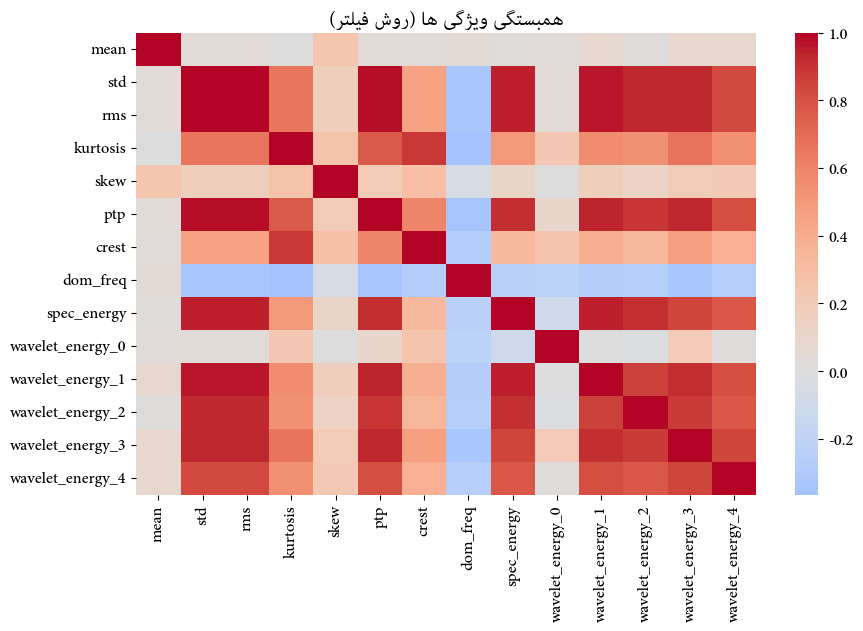

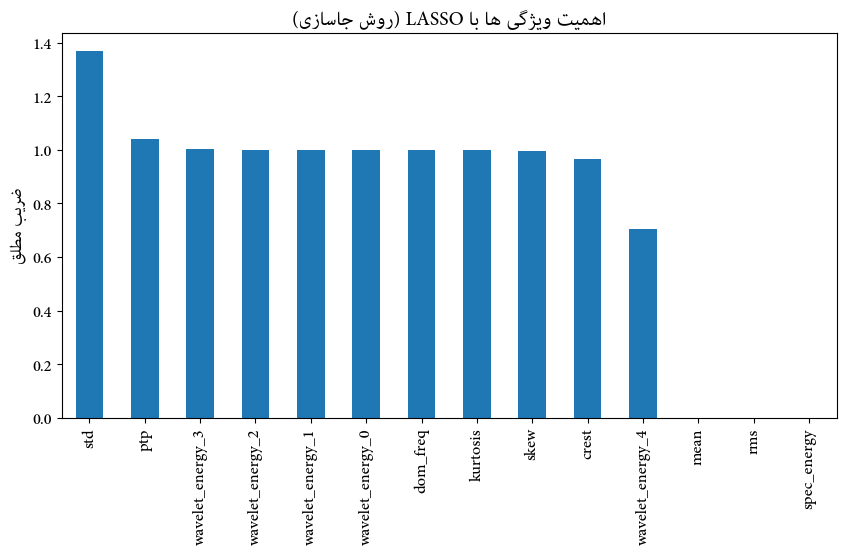

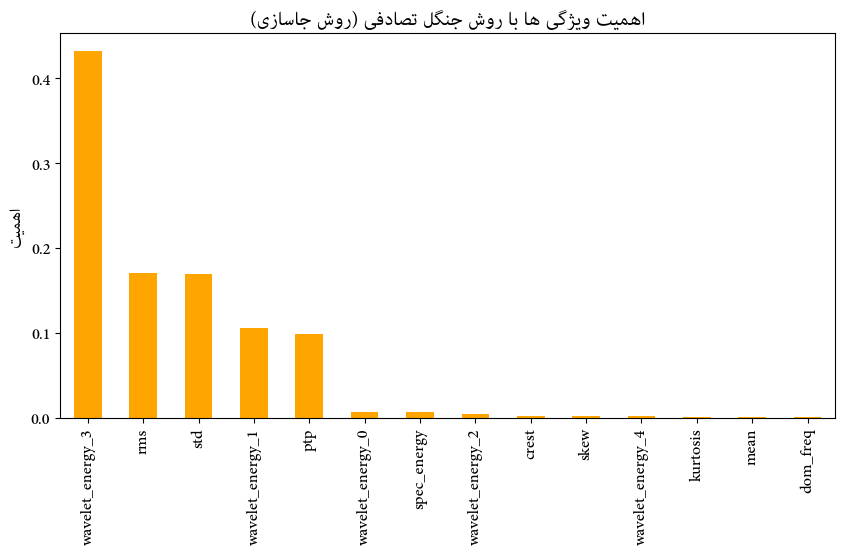

🔹 ویژگی های انتخاب شده (فیلتر): ['std', 'rms', 'kurtosis', 'skew', 'ptp', 'crest', 'dom_freq', 'wavelet_energy_0', 'wavelet_energy_1', 'wavelet_energy_2', 'wavelet_energy_3']
🔹 بهترین ویژگی بر اساس پوششی: ['dom_freq'] امتیاز: 0.9812667002284787
🔹 ویژگی های مهم بر اساس LASSO: ['std', 'kurtosis', 'skew', 'ptp', 'crest', 'dom_freq', 'wavelet_energy_0', 'wavelet_energy_1', 'wavelet_energy_2', 'wavelet_energy_3', 'wavelet_energy_4']
🔹5 ویژگی مهم بر اساس روش جنگ تصادفی: ['wavelet_energy_3', 'rms', 'std', 'wavelet_energy_1', 'ptp']


In [9]:
# همبستگی ویژگی ها (برای روش فیلتر)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title(fa("همبستگی ویژگی ها (روش فیلتر)"))
plt.show()

# اهمیت ویژگی ها با LASSO
plt.figure(figsize=(10, 5))
lasso_importance.sort_values(ascending=False).plot(kind="bar")
plt.title(fa("اهمیت ویژگی ها با LASSO (روش جاسازی)"))
plt.ylabel(fa("ضریب مطلق"))
plt.show()

# اهمیت ویژگی ها با روش جنگل تصادفی
plt.figure(figsize=(10, 5))
rf_importance.sort_values(ascending=False).plot(kind="bar", color="orange")
plt.title(fa("اهمیت ویژگی ها با روش جنگل تصادفی (روش جاسازی)"))
plt.ylabel(fa("اهمیت"))
plt.show()

# نمایش بهترین ویژگی بر اساس روش پوششی
print("🔹 ویژگی های انتخاب شده (فیلتر):", list(selected_features_filter))
print("🔹 بهترین ویژگی بر اساس پوششی:", best_feats, "امتیاز:", best_score)
print("🔹 ویژگی های مهم بر اساس LASSO:", list(lasso_importance[lasso_importance > 0].index))
print("🔹5 ویژگی مهم بر اساس روش جنگ تصادفی:", list(rf_importance.sort_values(ascending=False).head(5).index))